# Modeling_OLS_interpretation

OLS 예측 단계에서 확정한 `final_aic_features`를 사용해 **전체 데이터**로 재적합하고, 변수의 효과를 해석한다.

- β 부호·크기, HC3 robust p-value, 표준화 β
- 변수 그룹별 요약
- 잔차 진단 (전체 데이터 기준 재확인)
- LGBM(SHAP) 해석과 비교하기 위한 산출물 저장

변수 선택은 하지 않는다. (이미 `final_features.json` 확정)

## 1. 설정 로드

In [1]:
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import acorr_ljungbox, het_breuschpagan
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from IPython.display import display, Markdown

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

BASELINE_DIR = Path("../outputs/baseline")
CONFIG_PATH = BASELINE_DIR / "final_features.json"

with open(CONFIG_PATH, encoding="utf-8") as f:
    cfg = json.load(f)

TARGET = cfg["target"]
SPLIT_DATE = cfg["split_date"]
FINAL_FEATURES = list(cfg["final_aic_features"])
DATA_FILE_NAME = cfg["data_file"]

print("TARGET       :", TARGET)
print("SPLIT_DATE   :", SPLIT_DATE, "(참고용, 해석은 전체 데이터)")
print("DATA_FILE    :", DATA_FILE_NAME)
print("n_features   :", len(FINAL_FEATURES))
print("\nfinal_aic_features:")
for c in FINAL_FEATURES:
    print("  -", c)

TARGET       : oil_diff_target
SPLIT_DATE   : 2022-07-20 (참고용, 해석은 전체 데이터)
DATA_FILE    : dataset4_derived_full_with_dummies.csv
n_features   : 19

final_aic_features:
  - OilPrice
  - RealInterestRate
  - VIX
  - IndustryProduction
  - CPE
  - OilInventories
  - OPECProduction
  - TreasuryYield
  - oil_diff_lag1
  - MA_ratio
  - MA_5_gt_MA_20
  - vix_high
  - is_friday
  - gfc_2008_shock
  - gfc_2008_regime
  - opec_2014_window
  - covid_2020_window
  - war_2022_window
  - cond_opec_cut


In [2]:
# 데이터 로드: 예측 노트북과 동일한 전처리 (date 인덱스, 정렬, 결측 제거)
DATA_PATH = Path("../data/Finance_Final") / DATA_FILE_NAME

cols = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
if "date" in cols:
    DATE_COL = "date"
elif "Date" in cols:
    DATE_COL = "Date"
else:
    DATE_COL = cols[0]

df = pd.read_csv(DATA_PATH, parse_dates=[DATE_COL])
df = df.rename(columns={DATE_COL: "date"}).set_index("date").sort_index()
df_model = df.dropna().copy()

missing = [c for c in FINAL_FEATURES + [TARGET] if c not in df_model.columns]
if missing:
    raise ValueError(f"필수 컬럼 누락: {missing}")

print("shape:", df_model.shape)
print("기간 :", df_model.index.min().date(), "~", df_model.index.max().date())
print("n_obs:", len(df_model))

shape: (4547, 43)
기간 : 2008-01-31 ~ 2026-03-13
n_obs: 4547


## 2. 전체 데이터 OLS 재적합

In [3]:
X_all = sm.add_constant(df_model[FINAL_FEATURES], has_constant="add")
y_all = df_model[TARGET]

ols_plain = sm.OLS(y_all, X_all).fit()
ols_hc3   = sm.OLS(y_all, X_all).fit(cov_type="HC3")

print("===== OLS (일반 SE) =====")
print(ols_plain.summary())
print("\n===== OLS (HC3 robust SE) =====")
print(ols_hc3.summary())

===== OLS (일반 SE) =====
                            OLS Regression Results                            
Dep. Variable:        oil_diff_target   R-squared:                       0.040
Model:                            OLS   Adj. R-squared:                  0.036
Method:                 Least Squares   F-statistic:                     9.990
Date:                Thu, 21 May 2026   Prob (F-statistic):           1.78e-29
Time:                        00:23:24   Log-Likelihood:                -9605.1
No. Observations:                4547   AIC:                         1.925e+04
Df Residuals:                    4527   BIC:                         1.938e+04
Df Model:                          19                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
const       

## 3. 핵심 계수 표 (HC3 기준)

In [4]:
def sig_stars(p):
    if pd.isna(p):
        return ""
    if p < 0.01:
        return "***"
    if p < 0.05:
        return "**"
    if p < 0.10:
        return "*"
    return ""

rows = []
for v in FINAL_FEATURES:
    coef = ols_hc3.params[v]
    se   = ols_hc3.bse[v]
    tval = ols_hc3.tvalues[v]
    pval = ols_hc3.pvalues[v]
    std_b = coef * df_model[v].std()
    rows.append({
        "variable":     v,
        "coef":         coef,
        "SE_HC3":       se,
        "t_HC3":        tval,
        "p_HC3":        pval,
        "sig":          sig_stars(pval),
        "std_beta":     std_b,
        "abs_std_beta": abs(std_b),
    })

coef_df = pd.DataFrame(rows)

print("===== 정렬: p_HC3 오름차순 (유의성 우선) =====")
display(coef_df.sort_values("p_HC3").round(6).reset_index(drop=True))

print("\n===== 정렬: abs_std_beta 내림차순 (효과 크기 우선) =====")
display(coef_df.sort_values("abs_std_beta", ascending=False).round(6).reset_index(drop=True))

===== 정렬: p_HC3 오름차순 (유의성 우선) =====


,variable,coef,SE_HC3,t_HC3,p_HC3,sig,std_beta,abs_std_beta
0,opec_2014_window,-1.005994,0.472601,-2.128634,0.033285,**,-0.064901,0.064901
1,oil_diff_lag1,-0.068290,0.034677,-1.969307,0.048918,**,-0.139351,0.139351
2,cond_opec_cut,-0.169825,0.089435,-1.898858,0.057583,*,-0.073311,0.073311
3,CPE,-0.001396,0.000760,-1.837711,0.066105,*,-0.219413,0.219413
4,OPECProduction,-0.000184,0.000104,-1.765651,0.077454,*,-0.111336,0.111336
5,RealInterestRate,-0.293622,0.173249,-1.694798,0.090114,*,-0.059646,0.059646
6,gfc_2008_regime,0.499118,0.307870,1.621196,0.104976,,0.081301,0.081301
7,MA_5_gt_MA_20,0.346636,0.232961,1.487960,0.136761,,0.172772,0.172772
8,MA_ratio,-4.874492,3.343065,-1.458091,0.144816,,-0.286880,0.286880
9,IndustryProduction,0.082998,0.060059,1.381949,0.166988,,0.104493,0.104493



===== 정렬: abs_std_beta 내림차순 (효과 크기 우선) =====


,variable,coef,SE_HC3,t_HC3,p_HC3,sig,std_beta,abs_std_beta
0,OilPrice,-0.158226,0.141217,-1.120439,0.262527,,-0.322940,0.322940
1,MA_ratio,-4.874492,3.343065,-1.458091,0.144816,,-0.286880,0.286880
2,CPE,-0.001396,0.000760,-1.837711,0.066105,*,-0.219413,0.219413
3,MA_5_gt_MA_20,0.346636,0.232961,1.487960,0.136761,,0.172772,0.172772
4,oil_diff_lag1,-0.068290,0.034677,-1.969307,0.048918,**,-0.139351,0.139351
5,war_2022_window,1.643934,1.337287,1.229306,0.218957,,0.111474,0.111474
6,OPECProduction,-0.000184,0.000104,-1.765651,0.077454,*,-0.111336,0.111336
7,gfc_2008_shock,-0.864974,0.701453,-1.233118,0.217532,,-0.110901,0.110901
8,IndustryProduction,0.082998,0.060059,1.381949,0.166988,,0.104493,0.104493
9,covid_2020_window,-1.420482,1.223818,-1.160697,0.245765,,-0.096322,0.096322


## 4. 변수 그룹별 해석

- **가격/추세**: `MA_*`, `oil_momentum_*`, `oil_diff_lag*`
- **변동성**: `oil_volatility_*`
- **거시**: VIX, DollarIndex, RealInterestRate, CPI, TreasuryYield, FedFundsRate, TermSpread_*
- **더미/이벤트**: `is_monday`, `is_friday`, `vix_high`, `*_shock`, `*_regime`, `*_window`
- **기타**: 위 패턴에 매칭되지 않는 변수 (수급/펀더멘털 등)

In [5]:
MACRO_SET = {"VIX", "DollarIndex", "RealInterestRate", "CPI",
             "TreasuryYield", "FedFundsRate"}
DUMMY_EXACT = {"is_monday", "is_friday", "vix_high"}

def classify(v):
    if v.startswith("MA_") or v.startswith("oil_momentum_") or v.startswith("oil_diff_lag"):
        return "가격/추세"
    if v.startswith("oil_volatility_"):
        return "변동성"
    if v in MACRO_SET or v.startswith("TermSpread_"):
        return "거시"
    if v in DUMMY_EXACT or v.endswith("_shock") or v.endswith("_regime") or v.endswith("_window"):
        return "더미/이벤트"
    return "기타"

coef_df["group"] = coef_df["variable"].map(classify)

print("===== 변수별 그룹 분류 =====")
display(coef_df[["variable", "group", "coef", "std_beta", "p_HC3", "sig"]]
        .sort_values(["group", "abs_std_beta"], ascending=[True, False]) if False
        else coef_df[["variable", "group", "coef", "std_beta", "p_HC3", "sig"]]
             .assign(_a=coef_df["abs_std_beta"])
             .sort_values(["group", "_a"], ascending=[True, False])
             .drop(columns="_a")
             .reset_index(drop=True)
             .round(6))

def group_summary(g):
    n = len(g)
    n_sig = int((g["p_HC3"] < 0.05).sum())
    mean_abs_std = g["abs_std_beta"].mean()
    n_pos = int((g["coef"] > 0).sum())
    n_neg = int((g["coef"] < 0).sum())
    return pd.Series({
        "n_vars":         n,
        "n_sig_0.05":     n_sig,
        "mean_abs_std_beta": mean_abs_std,
        "n_positive":     n_pos,
        "n_negative":     n_neg,
    })

group_df = (coef_df.groupby("group")
                   .apply(group_summary)
                   .reset_index()
                   .sort_values("mean_abs_std_beta", ascending=False))

print("\n===== 그룹별 효과 요약 =====")
display(group_df.round(6).reset_index(drop=True))

===== 변수별 그룹 분류 =====


,variable,group,coef,std_beta,p_HC3,sig
0,MA_ratio,가격/추세,-4.874492,-0.286880,0.144816,
1,MA_5_gt_MA_20,가격/추세,0.346636,0.172772,0.136761,
2,oil_diff_lag1,가격/추세,-0.068290,-0.139351,0.048918,**
3,TreasuryYield,거시,1.158938,0.067139,0.258958,
4,RealInterestRate,거시,-0.293622,-0.059646,0.090114,*
5,VIX,거시,-0.029483,-0.059124,0.177360,
6,OilPrice,기타,-0.158226,-0.322940,0.262527,
7,CPE,기타,-0.001396,-0.219413,0.066105,*
8,OPECProduction,기타,-0.000184,-0.111336,0.077454,*
9,IndustryProduction,기타,0.082998,0.104493,0.166988,



===== 그룹별 효과 요약 =====


/var/folders/r4/cqk5gmns2z3gl1_8c6wsr4qh0000gn/T/ipykernel_44957/4206488143.py:43: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(group_summary)


,group,n_vars,n_sig_0.05,mean_abs_std_beta,n_positive,n_negative
0,가격/추세,3.0,1.0,0.199668,1.0,2.0
1,기타,6.0,0.0,0.141711,1.0,5.0
2,더미/이벤트,7.0,1.0,0.081406,2.0,5.0
3,거시,3.0,0.0,0.061970,1.0,2.0


## 5. 잔차 진단 (전체 데이터 기준)

In [6]:
resid = ols_hc3.resid
exog  = ols_hc3.model.exog

# Durbin-Watson
dw = durbin_watson(resid)

# Ljung-Box at lag 5, 10, 20
lb = acorr_ljungbox(resid, lags=[5, 10, 20], return_df=True)

# Breusch-Pagan
bp_stat, bp_p, bp_f, bp_fp = het_breuschpagan(resid, exog)

diag_table = pd.DataFrame({
    "통계":      ["Durbin-Watson",
                  "Ljung-Box (lag 5)",
                  "Ljung-Box (lag 10)",
                  "Ljung-Box (lag 20)",
                  "Breusch-Pagan (LM)"],
    "값":        [dw,
                  float(lb.loc[5,  "lb_stat"]),
                  float(lb.loc[10, "lb_stat"]),
                  float(lb.loc[20, "lb_stat"]),
                  bp_stat],
    "p-value":   [np.nan,
                  float(lb.loc[5,  "lb_pvalue"]),
                  float(lb.loc[10, "lb_pvalue"]),
                  float(lb.loc[20, "lb_pvalue"]),
                  bp_p],
})
display(diag_table.round(6))

# 자동 판정
lb10_p = float(lb.loc[10, "lb_pvalue"])
auto_corr = lb10_p < 0.05
hetero    = bp_p < 0.05

msg_auto = "있음 (Ljung-Box lag10 p < 0.05)" if auto_corr else "없음"
msg_het  = "있음 (Breusch-Pagan p < 0.05) — HC3 robust SE 사용 정당화" if hetero else "없음"
msg_dw   = "DW≈2 정상 범위" if 1.5 < dw < 2.5 else "DW 2에서 벗어남 (자기상관 의심)"

print("\n[자동 판정]")
print(f"  자기상관: {msg_auto}")
print(f"  이분산성: {msg_het}")
print(f"  Durbin-Watson = {dw:.4f} → {msg_dw}")

,통계,값,p-value
0,Durbin-Watson,1.997070,NaN
1,Ljung-Box (lag 5),4.801828,0.440541
2,Ljung-Box (lag 10),7.067202,0.719086
3,Ljung-Box (lag 20),26.126764,0.161666
4,Breusch-Pagan (LM),206.798326,0.000000



[자동 판정]
  자기상관: 없음
  이분산성: 있음 (Breusch-Pagan p < 0.05) — HC3 robust SE 사용 정당화
  Durbin-Watson = 1.9971 → DW≈2 정상 범위


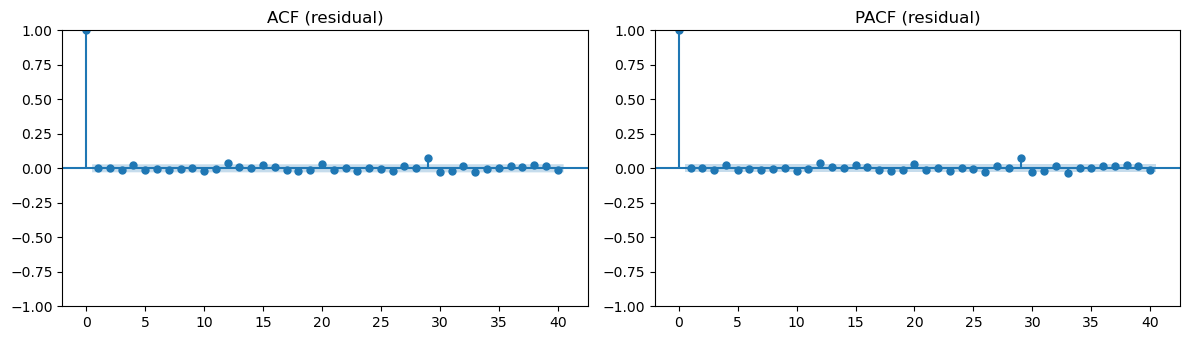

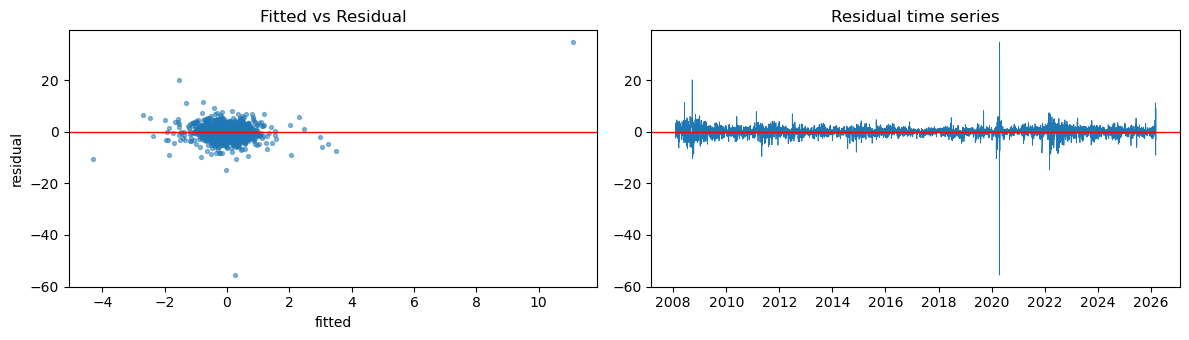

In [7]:
# ACF / PACF
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
plot_acf(resid,  lags=40, ax=axes[0]); axes[0].set_title("ACF (residual)")
plot_pacf(resid, lags=40, ax=axes[1], method="ywm"); axes[1].set_title("PACF (residual)")
plt.tight_layout(); plt.show()

# 적합값 vs 잔차 / 잔차 시계열
fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].scatter(ols_hc3.fittedvalues, resid, s=8, alpha=0.5)
axes[0].axhline(0, color="red", lw=1)
axes[0].set_xlabel("fitted"); axes[0].set_ylabel("residual")
axes[0].set_title("Fitted vs Residual")

axes[1].plot(resid.index, resid, lw=0.6)
axes[1].axhline(0, color="red", lw=1)
axes[1].set_title("Residual time series")
plt.tight_layout(); plt.show()

## 6. LGBM 해석 비교용 데이터 저장

In [8]:
BASELINE_DIR.mkdir(parents=True, exist_ok=True)

out_coef = coef_df[["variable", "coef", "SE_HC3", "p_HC3", "std_beta", "sig"]]
out_coef_path = BASELINE_DIR / "ols_interpretation_coefficients.csv"
out_coef.to_csv(out_coef_path, index=False, encoding="utf-8-sig")
print("저장:", out_coef_path)

out_group_path = BASELINE_DIR / "ols_interpretation_groups.csv"
group_df.to_csv(out_group_path, index=False, encoding="utf-8-sig")
print("저장:", out_group_path)

저장: ../outputs/baseline/ols_interpretation_coefficients.csv
저장: ../outputs/baseline/ols_interpretation_groups.csv


## 7. 해석 가이드 표 (OLS β × LGBM SHAP 케이스)

이 표는 LGBM 해석 노트북에서 변수별 실제 매칭에 사용한다.

| 케이스 | OLS 양상 | LGBM SHAP 양상 | 해석 |
| :-- | :-- | :-- | :-- |
| 1 | 부호·크기 일치 | 부호·크기 일치 | 견고한 효과 (linear & nonlinear 모두 지지) |
| 2 | 부호 일치, OLS β 작음 | SHAP 큼 | 선형은 약하나 비선형 추가 효과가 존재 |
| 3 | OLS β 큼 | SHAP 작음 | 선형으로 충분히 설명됨, 트리 모델이 활용 못함 |
| 4 | 무의미 (p_HC3 ≥ 0.05) | SHAP 큼 | 순수 비선형 효과 (OLS는 포착 실패) |
| 5 | 부호 불일치 | – | 상호작용/조건부 효과 의심, 추가 진단 필요 |

**활용:** LGBM 해석 노트북에서 `ols_interpretation_coefficients.csv`를 로드해 변수별 (coef sign, abs_std_beta, p_HC3)를 가져오고, 동일 변수의 mean(|SHAP|) / SHAP sign과 매칭하여 위 5가지 케이스 중 어디에 속하는지 라벨링한다.

## 최종결론

[흐름]
1. OLS prediction 단계에서 선택된 최종 변수 로드: 19개
2. 전체 데이터 기준 OLS 재적합
3. HC3 robust SE 기준 계수 해석
4. 표준화 계수 기준 효과 크기 확인
5. 변수 그룹별 해석
6. 잔차진단

[해석]

OLS interpretation에서는 Prediction 단계에서 AIC stepwise로 선택된 19개 변수를 고정한 뒤, 전체 데이터에 대해 OLS를 재적합하여 각 변수의 선형 효과를 해석하였다. 잔차진단 결과 자기상관은 확인되지 않았으나 이분산성이 존재했기 때문에, 계수의 유의성은 일반 표준오차가 아닌 HC3 robust standard error 기준으로 판단하였다.

1. HC3 기준 5% 유의 변수: `opec_2014_window`(-), `oil_diff_lag1`(-)
-  OPEC 2014 이벤트 구간에 해당하는 시기에는, 다른 조건이 같을 때 다음 시점의 유가 변화율이 낮아지는 경향이 있음을 의미한다. 
- 직전 시점의 유가 변화율이 높았을수록 다음 시점의 유가 변화율은 낮아지는 경향이 있음을 의미하며, 이는 단기적인 반전 효과를 시사한다.

2. 표준화 계수 기준: 
- `OilPrice`, `MA_ratio`, `CPE`, `MA_5_gt_MA_20`, `oil_diff_lag1`의 상대적 영향이 크다. 
- `OilPrice`, `MA_ratio`, `MA_5_gt_MA_20`은 HC3 기준 5% 수준에서 유의하지 않았으므로, 효과 크기와 통계적 유의성을 구분해 해석할 필요가 있다.

3. 변수 그룹별: 
- 가격/추세 그룹의 평균 절대 표준화 계수가 가장 크다
- 가격/추세 그룹과 더미/이벤트 그룹에서 5% 유의 변수가 각각 1개씩 확인되었다. 

=> 따라서 OLS 기준에서는 가격/추세 정보와 일부 이벤트 변수가 제한적으로 유가 변화율의 선형 관계를 설명한다고 볼 수 있다.

종합하면, 최종 OLS baseline의 선형 설명력은 Adj R² 기준 약 0.036으로 크지 않지만, `oil_diff_lag1`과 `opec_2014_window`는 HC3 기준에서 유의한 선형 효과를 보였다. 따라서 OLS는 강한 예측모형이라기보다, 유가 변화율에 대한 제한적인 선형 관계와 주요 변수의 방향성을 확인하는 해석용 baseline으로 활용하는 것이 적절하다.